<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°08

**Objetivo**: Aplicar técnicas de **machine learning no supervisado** para explorar, procesar y analizar conjuntos de datos con variables numéricas y categóricas.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


## Clustering


<img src="https://www.svgrepo.com/show/253022/car.svg" width = "300" align="center"/>



El conjunto de datos **`vehiculos_procesado_con_grupos.csv`** recopila información sobre diversas características relevantes de distintos vehículos. El propósito de este ejercicio es **clasificar los vehículos en diferentes categorías**, utilizando como base las variables descritas en la tabla de atributos.

El análisis presenta un desafío adicional debido a la **naturaleza mixta de los datos**: se incluyen tanto variables **numéricas** (ej. dimensiones, consumo, emisiones) como **categóricas** (ej. tipo de tracción, tipo de combustible), lo que requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

Como primer paso, procederemos a **cargar y explorar el conjunto de datos**, con el fin de familiarizarnos con su estructura y las características que servirán como base para la posterior clasificación.




**Descripción de los Datos:**

| **Nombre de la Columna**   | **Descripción**                                                                                                                                   |
|----------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| **year**                   | El año en que el vehículo fue fabricado.                                                                                                          |
| **desplazamiento**          | La capacidad volumétrica del motor en litros. Indica la cantidad de aire y combustible que puede desplazar el motor durante una revolución.       |
| **cilindros**               | El número de cilindros que tiene el motor. Los cilindros son las cámaras donde ocurre la combustión interna en los motores de los vehículos.       |
| **co2**                     | Emisiones de dióxido de carbono del vehículo, medido en gramos por kilómetro. Es una medida de las emisiones de gases de efecto invernadero.       |
| **clase_tipo**              | La clase o tipo de vehículo, como vehículos especiales, deportivos, etc.                                                                         |
| **traccion_tipo**           | Tipo de tracción del vehículo, ya sea tracción en dos ruedas, en cuatro ruedas o en todas las ruedas.                                             |
| **transmision_tipo**        | Tipo de transmisión del vehículo, como automática, manual, entre otros.                                                                          |
| **combustible_tipo**        | Tipo de combustible que utiliza el vehículo, como gasolina, diésel, eléctrico, híbrido, etc.                                                     |
| **tamano_motor_tipo**       | Clasificación del tamaño del motor (por ejemplo, pequeño, mediano o grande), que generalmente se basa en la capacidad de desplazamiento.           |
| **consumo_tipo**            | Clasificación del nivel de consumo de combustible del vehículo, indicando si es alto, bajo, o muy alto.                                           |
| **co2_tipo**                | Clasificación de las emisiones de CO2 del vehículo, indicando si es alto, bajo, o muy alto.                                                       |
| **consumo_litros_milla**    | El consumo de combustible del vehículo, medido en litros por milla. Indica la eficiencia del vehículo en términos de consumo de combustible.        |



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans


%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [4]:
# cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],

          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


In [5]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Normalizar datos

# Identificar variables numéricas y categóricas
numerical_cols = ['year', 'desplazamiento', 'cilindros', 'co2', 'consumo_litros_milla']
categorical_cols = ['clase_tipo', 'traccion_tipo', 'transmision_tipo', 'combustible_tipo', 'tamano_motor_tipo', 'consumo_tipo', 'co2_tipo']

# Crear un conjunto de datos con variables numéricas
df_numerical = df[numerical_cols].copy()

# Rellenar datos vacíos con el promedio de cada columna numérica
for col in df_numerical.columns:
    df_numerical[col].fillna(df_numerical[col].mean(), inplace=True)

# Normalizar datos numéricos usando MinMaxScaler
scaler = MinMaxScaler()
df_numerical_scaled = pd.DataFrame(scaler.fit_transform(df_numerical), columns=numerical_cols)

# Crear un conjunto de datos con variables categóricas
df_categorical = df[categorical_cols].copy()

# Transformar variables categóricas a numéricas usando get_dummies
df_categorical_encoded = pd.get_dummies(df_categorical)

# Unir ambos datasets en uno, llamado df_procesado
df_procesado = pd.concat([df_numerical_scaled, df_categorical_encoded], axis=1)

display(df_procesado.head())
display(df_procesado.info())

/tmp/ipykernel_522/1381464140.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_numerical[col].fillna(df_numerical[col].mean(), inplace=True)


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.000000,0.243590,0.142857,0.398014,0.331027,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,0.000000,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0.029412,0.243590,0.142857,0.424351,0.360294,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,0.029412,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.088235,0.410256,0.285714,0.424351,0.360294,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36791 entries, 0 to 36790
Data columns (total 36 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   year                                         36791 non-null  float64
 1   desplazamiento                               36791 non-null  float64
 2   cilindros                                    36791 non-null  float64
 3   co2                                          36791 non-null  float64
 4   consumo_litros_milla                         36791 non-null  float64
 5   clase_tipo_Camionetas                        36791 non-null  bool   
 6   clase_tipo_Coche Familiar                    36791 non-null  bool   
 7   clase_tipo_Coches Grandes                    36791 non-null  bool   
 8   clase_tipo_Coches Medianos                   36791 non-null  bool   
 9   clase_tipo_Coches pequeños                   36791 non-null  bool   
 10

None

La función `pd.get_dummies()` de pandas es una herramienta utilizada para la codificación "One-Hot" de variables categóricas. Esta técnica convierte cada categoría única de una columna en una nueva columna binaria (0 o 1). Por ejemplo, si una columna `color` tiene valores `['rojo', 'azul', 'verde']`, `get_dummies()` creará tres nuevas columnas: `color_rojo`, `color_azul` y `color_verde`.

- Si una fila tiene `color='rojo'`, la columna `color_rojo` tendrá un `1` y las otras dos `0`.
- Si una fila tiene `color='azul'`, la columna `color_azul` tendrá un `1` y las otras dos `0`.

Este proceso es fundamental en machine learning, ya que la mayoría de los algoritmos no pueden trabajar directamente con variables categóricas textuales y requieren representaciones numéricas.

En este caso, no solo se tienen datos numéricos, sino que también categóricos. Además, tenemos problemas de datos **vacíos (Nan)**. Así que para resolver este problema, seguiremos varios pasos:

### 1.- Normalizar datos

- Cree un conjunto de datos con las variables numéricas, además, para cada dato vacía, rellene con el promedio asociado a esa columna. Finalmente, normalize los datos mediante el procesamiento **MinMaxScaler** de **sklearn**.
- Cree un conjunto de datos con las variables categóricas , además, transforme de variables categoricas a numericas ocupando el comando **get_dummies** de pandas ([referencia](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)). Explique a grande rasgo como se realiza la codificación de variables numéricas a categóricas.

- Junte ambos dataset en uno, llamado **df_procesado**.

In [6]:
# FIXME

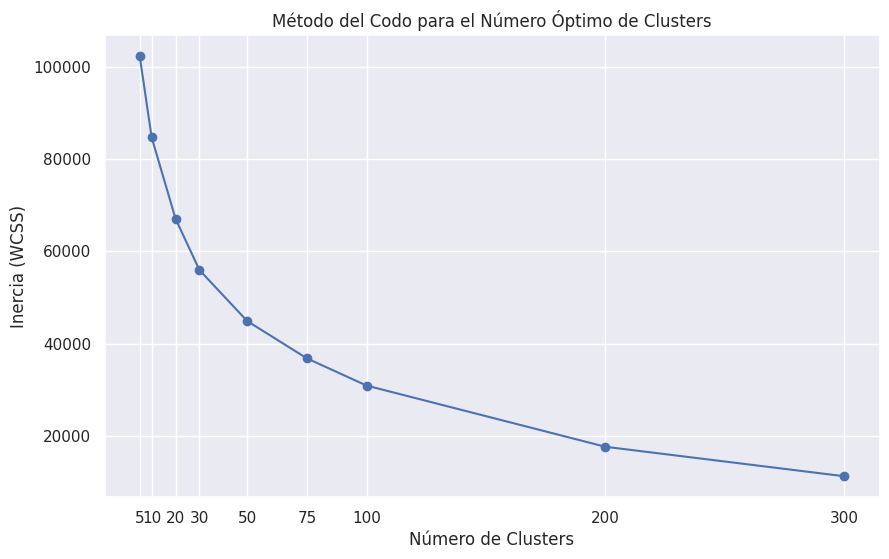

In [15]:
# 3. Elegir Número de cluster

# Definir la secuencia de número de clusters a comparar
cluster_range = [5, 10, 20, 30, 50, 75, 100, 200, 300]

# Lista para almacenar la inercia (WCSS - Within-Cluster Sum of Squares)
inertias = []

# Calcular la inercia para cada número de clusters
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(df_procesado.drop('cluster', axis=1))
    inertias.append(kmeans.inertia_)

# Graficar la regla del codo
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertias, marker='o')
plt.title('Método del Codo para el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [7]:
from sklearn.cluster import KMeans

# 2. Realizar ajuste mediante kmeans

# 1. Ajustar el modelo de kmeans sobre el conjunto de datos con 8 clusters
kmeans_model = KMeans(n_clusters=8, random_state=42, n_init=10) # n_init para evitar warnings
kmeans_model.fit(df_procesado)

# 2. Asociar a cada individuo el correspondiente cluster
df_procesado['cluster'] = kmeans_model.labels_

# Calcular valor de los centroides de cada cluster
centroids = pd.DataFrame(kmeans_model.cluster_centers_, columns=df_procesado.drop('cluster', axis=1).columns)
display("Centroides de cada cluster:", centroids)

# 3. Realizar un resumen de las principales cualidades de cada cluster
# Valor promedio de las variables numéricas (todas las columnas en df_procesado son numéricas)
cluster_means = df_procesado.groupby('cluster').mean()
display("Promedio de variables por cluster:", cluster_means)

# Moda para las variables numéricas (todas las columnas en df_procesado son numéricas)
# La función mode() puede devolver múltiples modas, por lo que se usa .iloc[0] para obtener la primera si hay varias
cluster_modes = df_procesado.groupby('cluster').agg(lambda x: x.mode()[0])
display("Moda de variables por cluster:", cluster_modes)

'Centroides de cada cluster:'

,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.427318,0.223790,0.173637,0.304599,0.226412,0.126441,0.097434,0.004835,0.088137,0.517665,...,1.831868e-15,9.776869e-01,9.048318e-15,9.076073e-15,2.231313e-02,4.635181e-15,9.921904e-01,7.809595e-03,4.246603e-15,-1.201816e-14
1,0.569367,0.169607,0.146057,0.240820,0.156357,0.007990,0.117281,0.017606,0.138407,0.629063,...,-1.232348e-14,-1.679212e-14,1.354280e-04,-1.024181e-14,9.998646e-01,-9.103829e-15,1.218852e-03,8.125677e-04,8.160139e-15,9.979686e-01
2,0.407666,0.331397,0.256796,0.354288,0.282121,0.181278,0.084035,0.090474,0.133564,0.184580,...,-7.271961e-15,1.386825e-02,9.808486e-01,7.355228e-15,5.283143e-03,1.155688e-03,-1.712519e-14,9.988443e-01,-6.022960e-15,-1.582068e-15
3,0.476969,0.450984,0.327266,0.410019,0.343261,0.304450,0.017116,0.041506,0.048567,0.151048,...,9.584938e-01,-1.421085e-14,4.065041e-02,8.557980e-04,-6.578071e-15,9.957210e-01,7.494005e-16,6.418485e-04,3.637142e-03,-1.768030e-14
4,0.384236,0.585590,0.430797,0.510289,0.454503,0.259250,0.005599,0.059153,0.059396,0.197420,...,3.115871e-02,-1.321165e-14,1.168452e-02,9.571568e-01,-6.494805e-15,1.703992e-03,7.494005e-16,4.868549e-04,9.978092e-01,-1.662559e-14
5,0.588730,0.362290,0.299545,0.354136,0.282247,0.001505,0.083020,0.086531,0.189616,0.558816,...,5.016303e-04,2.608478e-02,9.731628e-01,1.360023e-14,2.508151e-04,2.357662e-02,7.771561e-16,9.764234e-01,-1.040834e-14,-1.634803e-14
6,0.452443,0.562730,0.405562,0.501887,0.442585,0.435441,0.001318,0.003953,0.010211,0.058300,...,5.764163e-02,-1.032507e-14,5.599473e-03,9.367589e-01,-6.300516e-15,6.883383e-15,7.216450e-16,-9.436896e-15,1.000000e+00,-1.357248e-14
7,0.579550,0.269830,0.210005,0.305067,0.226473,0.025947,0.094316,0.072488,0.192545,0.397446,...,6.177924e-04,9.619028e-01,8.237232e-04,1.523781e-14,3.665568e-02,2.969847e-15,9.684926e-01,2.944811e-02,-1.587619e-14,2.059308e-03


'Promedio de variables por cluster:'

,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.427318,0.223790,0.173637,0.304599,0.226412,0.126441,0.097434,0.004835,0.088137,0.517665,...,0.000000,0.977687,0.000000,0.000000,0.022313,0.000000,0.992190,0.007810,0.000000,0.000000
1,0.569367,0.169607,0.146057,0.240820,0.156357,0.007990,0.117281,0.017606,0.138407,0.629063,...,0.000000,0.000000,0.000135,0.000000,0.999865,0.000000,0.001219,0.000813,0.000000,0.997969
2,0.407666,0.331397,0.256796,0.354288,0.282121,0.181278,0.084035,0.090474,0.133564,0.184580,...,0.000000,0.013868,0.980849,0.000000,0.005283,0.001156,0.000000,0.998844,0.000000,0.000000
3,0.476969,0.450984,0.327266,0.410019,0.343261,0.304450,0.017116,0.041506,0.048567,0.151048,...,0.958494,0.000000,0.040650,0.000856,0.000000,0.995721,0.000000,0.000642,0.003637,0.000000
4,0.384236,0.585590,0.430797,0.510289,0.454503,0.259250,0.005599,0.059153,0.059396,0.197420,...,0.031159,0.000000,0.011685,0.957157,0.000000,0.001704,0.000000,0.000487,0.997809,0.000000
5,0.588730,0.362290,0.299545,0.354136,0.282247,0.001505,0.083020,0.086531,0.189616,0.558816,...,0.000502,0.026085,0.973163,0.000000,0.000251,0.023577,0.000000,0.976423,0.000000,0.000000
6,0.452443,0.562730,0.405562,0.501887,0.442585,0.435441,0.001318,0.003953,0.010211,0.058300,...,0.057642,0.000000,0.005599,0.936759,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
7,0.579550,0.269830,0.210005,0.305067,0.226473,0.025947,0.094316,0.072488,0.192545,0.397446,...,0.000618,0.961903,0.000824,0.000000,0.036656,0.000000,0.968493,0.029448,0.000000,0.002059


'Moda de variables por cluster:'

,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.179487,0.142857,0.317749,0.241830,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
1,0.970588,0.179487,0.142857,0.275108,0.194444,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,0.000000,0.307692,0.285714,0.374603,0.305011,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,0.029412,0.474359,0.285714,0.424351,0.331027,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
4,0.000000,0.564103,0.428571,0.454199,0.393464,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
5,0.617647,0.307692,0.285714,0.374603,0.281734,False,False,False,False,True,...,False,False,True,False,False,False,False,True,False,False
6,0.558824,0.653846,0.428571,0.454199,0.393464,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
7,0.970588,0.179487,0.142857,0.317749,0.241830,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False


### 2.- Realizar ajuste mediante kmeans

Una vez depurado el conjunto de datos, es momento de aplicar el algoritmo de **kmeans**.

1. Ajuste el modelo de **kmeans** sobre el conjunto de datos, con un total de **8 clusters**.
2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
3. Realizar un resumen de las principales cualidades de cada cluster. Para  esto debe calcular (para cluster) las siguientes medidas de resumen:
    * Valor promedio de las variables numérica
    * Moda para las variables numericas

In [8]:
# FIXME

### 3.- Elegir Número de cluster

Estime mediante la **regla del codo**, el número de cluster apropiados para el caso.
Para efectos prácticos, eliga la siguiente secuencia como número de clusters a comparar:

$$[5, 10, 20, 30, 50, 75, 100, 200, 300]$$

Una vez realizado el gráfico, saque sus propias conclusiones del caso.

In [9]:
# FIXME

Al observar el gráfico resultante, se pueden obtener conclusiones sobre el número apropiado de clusters. La regla del codo sugiere elegir el número de clusters donde la reducción en la inercia se estabiliza significativamente. En otras palabras, se busca el punto en el gráfico donde la curva de inercia comienza a aplanarse o forma un codo.

## Reducción de Dimensionalidad

<img src="https://1000logos.net/wp-content/uploads/2020/11/Wine-Logo-old.png" width = "300" align="center"/>


Para este ejercicio utilizaremos el **Wine Dataset**, un conjunto de datos clásico disponible en la librería **scikit-learn** y en el repositorio de la **UCI Machine Learning**.
Este dataset contiene información de **178 muestras de vino** provenientes de la región italiana de *Piamonte*. Cada vino pertenece a una de **tres variedades de uva** (*clases*), que actúan como etiquetas para el análisis supervisado, pero aquí se usarán solo como referencia en la visualización.

Cada muestra está descrita por **13 variables químicas** obtenidas de un análisis de laboratorio, entre ellas:

* **Alcohol**: porcentaje de alcohol en el vino.
* **Malic acid**: concentración de ácido málico.
* **Ash**: contenido de ceniza.
* **Alcalinity of ash**: alcalinidad de la ceniza.
* **Magnesium**: cantidad de magnesio (mg/L).
* **Total phenols**: concentración total de fenoles.
* **Flavanoids**: tipo de fenoles con propiedades antioxidantes.
* **Nonflavanoid phenols**: fenoles que no son flavonoides.
* **Proanthocyanins**: compuestos relacionados con el color y el sabor.
* **Color intensity**: intensidad del color del vino.
* **Hue**: matiz del color.
* **OD280/OD315 of diluted wines**: relación de absorbancia que mide la calidad del vino.
* **Proline**: concentración de prolina (un aminoácido).

Estas características permiten representar cada vino como un punto en un espacio de **13 dimensiones**.

El objetivo del análisis con este dataset es **reducir la dimensionalidad** para visualizar y explorar patrones en los datos. Para ello aplicaremos:

* **PCA (Principal Component Analysis):** identificar las combinaciones lineales de variables que explican la mayor varianza en el conjunto.
* **t-SNE (t-distributed Stochastic Neighbor Embedding):** mapear las muestras a 2D o 3D, preservando relaciones de vecindad y estructuras no lineales.

La comparación entre ambas técnicas permitirá observar cómo las tres clases de vinos se diferencian en el espacio reducido y discutir la utilidad de la reducción de dimensionalidad en datos con mayor número de variables que en el caso del dataset *Wine*.



In [10]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [11]:
# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0




### 1. **Análisis detallado con PCA**

* Calcular la **varianza explicada** por cada componente principal y representar el gráfico de varianza acumulada, identificando cuántos componentes son necesarios para capturar al menos el **90–95% de la información**.
* Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.
* Analizar los **loadings** (coeficientes de cada variable en los componentes) e interpretar qué características químicas del vino (alcohol, fenoles, color, etc.) tienen mayor influencia en las nuevas dimensiones.
* Visualizar los datos reducidos a 2D o 3D e interpretar si las **tres variedades de vino** se separan de forma clara en el espacio proyectado.



In [12]:
# FIXME

Se necesitan 8 componentes para capturar al menos el 90% de la varianza (aproximadamente 92.02%)
Se necesitan 9 componentes para capturar al menos el 90% de la varianza (aproximadamente 94.24%)
Se necesitan 10 componentes para capturar al menos el 95% de la varianza (aproximadamente 96.17%)


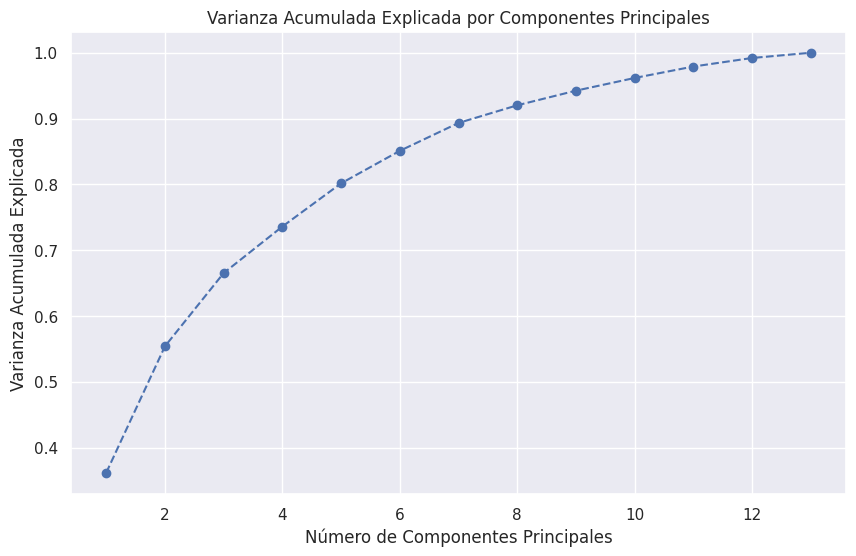

In [16]:
from sklearn.preprocessing import StandardScaler

# Separar las características (X) y la variable objetivo (y)
X = wine.drop('wine_class', axis=1)
y = wine['wine_class']

# Estandarizar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Varianza explicada por cada componente principal
# Calcular PCA con todos los componentes para analizar la varianza explicada
pca_full = PCA()
pca_full.fit(X_scaled)

# Varianza explicada por cada componente
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Graficar la varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)

# Identificar cuántos componentes son necesarios para capturar al menos el 90-95% de la información
for i, cum_var in enumerate(cumulative_explained_variance):
    if cum_var >= 0.90 and cum_var < 0.95:
        print(f"Se necesitan {i+1} componentes para capturar al menos el 90% de la varianza (aproximadamente {cum_var:.2%})")
    if cum_var >= 0.95:
        print(f"Se necesitan {i+1} componentes para capturar al menos el 95% de la varianza (aproximadamente {cum_var:.2%})")
        break

plt.show()

El gráfico de la varianza acumulada nos permite ver claramente cuántos componentes principales son necesarios para retener un porcentaje significativo de la información original. El 'codo' en el gráfico indica dónde la adición de nuevos componentes comienza a aportar menos información adicional.

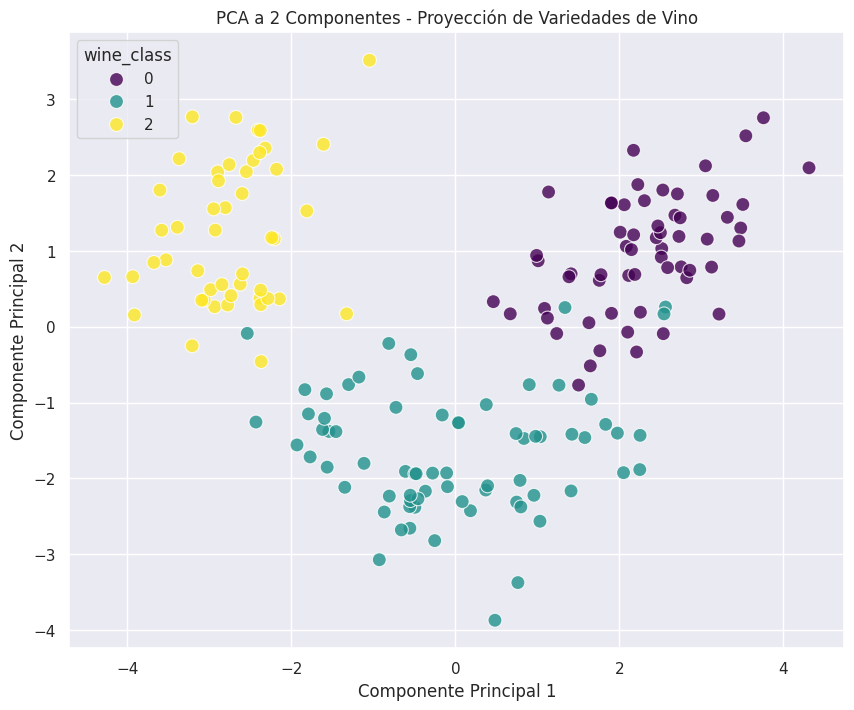

'Loadings para PCA a 2 Componentes:'

,PC1,PC2
alcohol,0.144329,0.483652
malic_acid,-0.245188,0.224931
ash,-0.002051,0.316069
alcalinity_of_ash,-0.239320,-0.010591
magnesium,0.141992,0.299634
total_phenols,0.394661,0.065040
flavanoids,0.422934,-0.003360
nonflavanoid_phenols,-0.298533,0.028779
proanthocyanins,0.313429,0.039302
color_intensity,-0.088617,0.529996


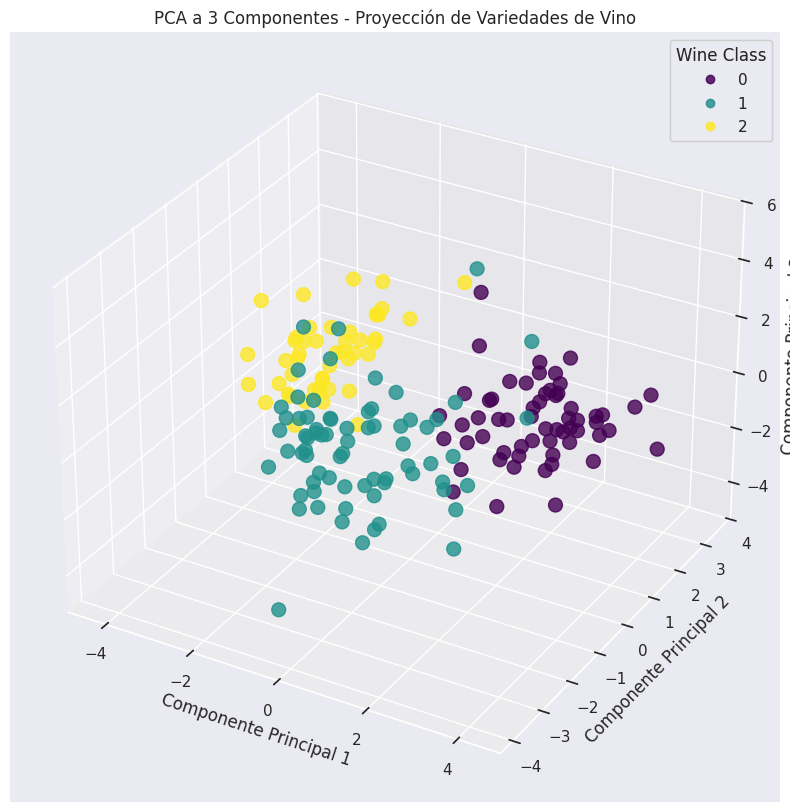

'Loadings para PCA a 3 Componentes:'

,PC1,PC2,PC3
alcohol,0.144329,0.483652,-0.207383
malic_acid,-0.245188,0.224931,0.089013
ash,-0.002051,0.316069,0.626224
alcalinity_of_ash,-0.239320,-0.010591,0.612080
magnesium,0.141992,0.299634,0.130757
total_phenols,0.394661,0.065040,0.146179
flavanoids,0.422934,-0.003360,0.150682
nonflavanoid_phenols,-0.298533,0.028779,0.170368
proanthocyanins,0.313429,0.039302,0.149454
color_intensity,-0.088617,0.529996,-0.137306


In [17]:
# PCA a 2 componentes
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Construir DataFrame con las proyecciones 2D
df_pca_2d = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['wine_class'] = y

# Visualizar los datos reducidos a 2D
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='wine_class', data=df_pca_2d, palette='viridis', s=100, alpha=0.8)
plt.title('PCA a 2 Componentes - Proyección de Variedades de Vino')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

# Loadings (contribución de las variables originales a cada componente)
loadings_2d = pd.DataFrame(pca_2d.components_.T, columns=['PC1', 'PC2'], index=features)
display("Loadings para PCA a 2 Componentes:", loadings_2d)

# PCA a 3 componentes
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Construir DataFrame con las proyecciones 3D
df_pca_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['wine_class'] = y

# Visualizar los datos reducidos a 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df_pca_3d['PC1'], df_pca_3d['PC2'], df_pca_3d['PC3'], c=df_pca_3d['wine_class'], cmap='viridis', s=100, alpha=0.8)

ax.set_title('PCA a 3 Componentes - Proyección de Variedades de Vino')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')

legend = ax.legend(*scatter.legend_elements(), title='Wine Class')
ax.add_artist(legend)

plt.show()

# Loadings para 3 componentes
loadings_3d = pd.DataFrame(pca_3d.components_.T, columns=['PC1', 'PC2', 'PC3'], index=features)
display("Loadings para PCA a 3 Componentes:", loadings_3d)

### Interpretación de los Resultados de PCA:

**Visualización 2D y 3D:**
*   Observa si las diferentes clases de vino (representadas por colores) forman grupos distintos en los gráficos 2D y 3D. ¿Están bien separadas o se superponen? Esto indica qué tan bien PCA puede diferenciar las variedades de vino.

**Loadings:**
*   Los loadings nos muestran la correlación entre las variables originales y los componentes principales. Un valor absoluto alto en un loading (ya sea positivo o negativo) indica que esa variable original contribuye significativamente a la construcción de ese componente principal.
*   Por ejemplo, si 'alcohol' tiene un loading alto y positivo en PC1, significa que PC1 captura mucha de la variabilidad relacionada con el contenido de alcohol. Si 'malic_acid' tiene un loading negativo alto en PC2, PC2 captura la variabilidad opuesta a la del ácido málico.
*   Al analizar los loadings de los primeros componentes principales, podemos inferir qué características químicas son las más influyentes en la diferenciación de los vinos.



### 2. **Análisis detallado con t-SNE**

* Aplicar **t-SNE** para reducir los datos a 2 dimensiones, probando diferentes configuraciones de hiperparámetros como *perplexity* y *learning rate*.
* Comparar las distintas visualizaciones obtenidas y discutir cómo los hiperparámetros afectan la estructura de los clústeres.
* Analizar si las **tres clases de vinos** forman agrupaciones definidas y si t-SNE logra capturar relaciones no lineales que PCA no refleja.



In [13]:
# FIXME

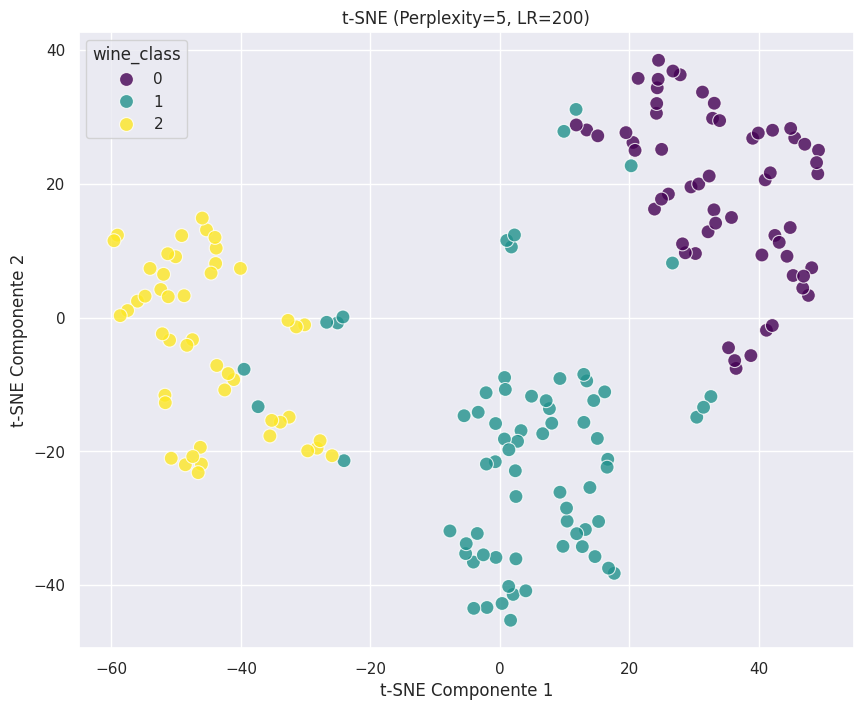

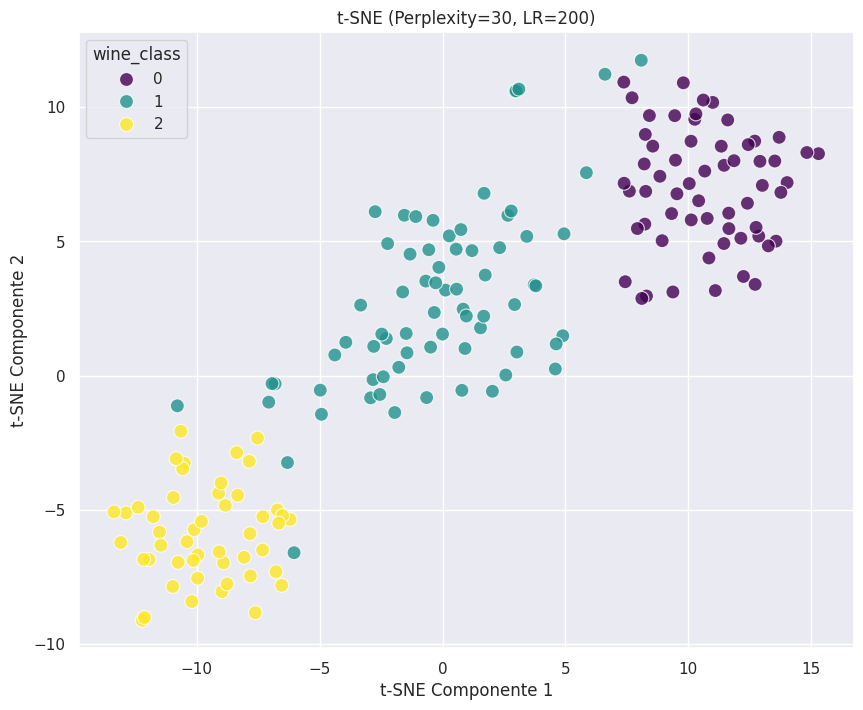

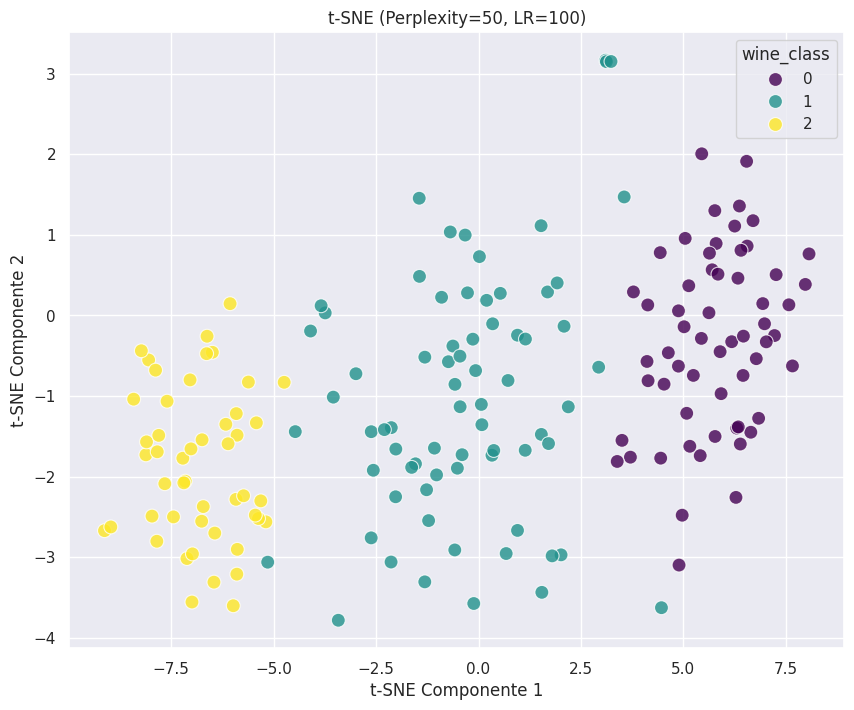

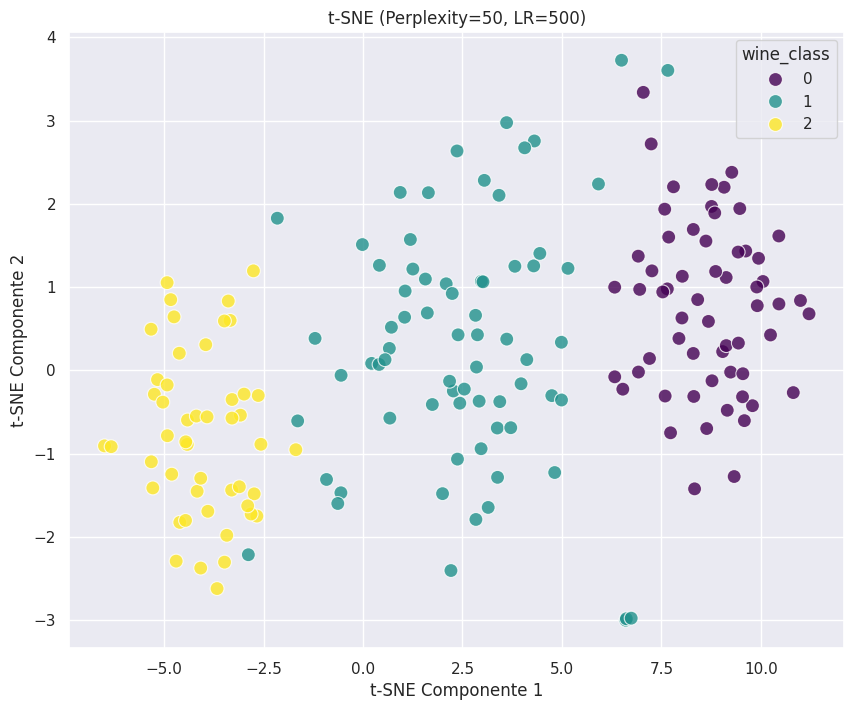

In [18]:
# 2. Análisis detallado con t-SNE

# Definir diferentes configuraciones de hiperparámetros para t-SNE
t_sne_configs = [
    {'perplexity': 5, 'learning_rate': 200, 'title': 't-SNE (Perplexity=5, LR=200)'},
    {'perplexity': 30, 'learning_rate': 200, 'title': 't-SNE (Perplexity=30, LR=200)'},
    {'perplexity': 50, 'learning_rate': 100, 'title': 't-SNE (Perplexity=50, LR=100)'},
    {'perplexity': 50, 'learning_rate': 500, 'title': 't-SNE (Perplexity=50, LR=500)'}
]

for config in t_sne_configs:
    tsne = TSNE(n_components=2, perplexity=config['perplexity'], learning_rate=config['learning_rate'], random_state=42, init='pca')
    X_tsne = tsne.fit_transform(X_scaled)

    # Construir DataFrame con las proyecciones 2D
    df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    df_tsne['wine_class'] = y

    # Visualizar los datos reducidos a 2D
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='TSNE1', y='TSNE2', hue='wine_class', data=df_tsne, palette='viridis', s=100, alpha=0.8)
    plt.title(config['title'])
    plt.xlabel('t-SNE Componente 1')
    plt.ylabel('t-SNE Componente 2')
    plt.grid(True)
    plt.show()

### Interpretación de los Resultados de t-SNE:

**Efecto de los Hiperparámetros:**
*   **Perplexity:** Controla el equilibrio entre el enfoque en las relaciones de datos locales y globales. Un valor bajo (ej. 5) hace que t-SNE se centre más en la estructura local, lo que puede resultar en clusters más pequeños y dispersos. Un valor alto (ej. 50) considera más vecinos, revelando estructuras más globales pero posiblemente perdiendo detalles finos.
*   **Learning Rate (Tasa de Aprendizaje):** Influye en la velocidad a la que se mueven los puntos durante la optimización. Un valor muy bajo puede hacer que la optimización sea lenta y quede atrapada en mínimos locales; un valor muy alto puede hacer que la optimización sea inestable y no converja.

**Agrupaciones por Clases de Vino:**
*   Observa cómo las diferentes configuraciones de `perplexity` y `learning_rate` afectan la separación de las tres clases de vino. ¿Se forman clusters distintos para cada clase? ¿Qué configuración parece ofrecer la mejor separación visual y agrupamiento cohesivo para cada clase?
*   t-SNE es especialmente bueno para revelar estructuras no lineales y agrupaciones que PCA podría pasar por alto. Compara las visualizaciones de t-SNE con las de PCA. ¿t-SNE logra una separación más clara entre las clases de vino, especialmente si hay relaciones complejas entre las características?



### 3. **Comparación entre PCA y t-SNE**

* Contrastar las visualizaciones y discutir las **ventajas y limitaciones** de cada técnica:

  * PCA como método **lineal** para interpretar varianza y relaciones globales.
  * t-SNE como método **no lineal** que preserva relaciones locales y vecindades.
* Evaluar en qué escenarios prácticos sería más recomendable usar PCA (interpretabilidad, reducción previa para modelos) o t-SNE (exploración y visualización de clústeres).
* Reflexionar sobre la **importancia de la reducción de dimensionalidad** en datasets de alta dimensión como Wine, destacando su utilidad para:

  * Visualizar patrones ocultos en los datos.
  * Reducir complejidad y ruido antes de aplicar algoritmos de aprendizaje automático.
  * Facilitar la interpretación y comunicación de resultados.



### 3. Comparación entre PCA y t-SNE

**Ventajas y Limitaciones:**

*   **PCA (Principal Component Analysis):**
    *   **Ventajas:** Es un método lineal, computacionalmente eficiente, y los componentes principales son interpretables como combinaciones lineales de las variables originales. Es útil para la reducción de ruido y para identificar las direcciones de máxima varianza en los datos, lo que puede ser valioso para la reducción de dimensionalidad previa a la construcción de modelos.
    *   **Limitaciones:** No es efectivo para capturar estructuras no lineales o relaciones complejas entre los datos. Si los clusters de datos tienen formas no lineales o están anidados, PCA puede no separarlos adecuadamente.

*   **t-SNE (t-distributed Stochastic Neighbor Embedding):**
    *   **Ventajas:** Es un método no lineal, excelente para la visualización de datos de alta dimensión, ya que es capaz de preservar las estructuras locales de los datos y las relaciones de vecindad. Es muy bueno para revelar clusters o agrupaciones que podrían estar ocultas en espacios de mayor dimensión.
    *   **Limitaciones:** Computacionalmente intensivo, especialmente para grandes conjuntos de datos. La interpretación de los ejes de t-SNE no es tan directa como en PCA; no tienen un significado físico inherente. Además, los resultados pueden ser sensibles a la elección de hiperparámetros (perplexity y learning rate), lo que requiere experimentación.

**Escenarios de Aplicación:**

*   **PCA:** Sería más recomendable usar PCA en escenarios donde la interpretabilidad de los componentes es crucial, cuando se necesita una reducción de dimensionalidad para reducir la complejidad computacional en algoritmos posteriores (por ejemplo, antes de aplicar un clasificador en un espacio de características más pequeño), o cuando se sospecha que la estructura de los datos es predominantemente lineal.

*   **t-SNE:** Es ideal para tareas de exploración de datos y visualización, especialmente cuando se buscan patrones o clusters en datos complejos y no lineales donde la separación lineal no es suficiente. Es particularmente útil para entender la estructura intrínseca de los datos en espacios de características muy grandes, como en el análisis genómico o el procesamiento de lenguaje natural.

**Importancia de la Reducción de Dimensionalidad en Datasets como Wine:**

La reducción de dimensionalidad es fundamental en datasets de alta dimensión como el de los vinos (13 características) por varias razones:

*   **Visualización:** Permite representar datos complejos en 2D o 3D, facilitando la identificación de patrones, clusters y outliers que serían imposibles de ver en el espacio original de 13 dimensiones. En el caso del vino, esto nos ayudó a visualizar la separación de las tres variedades.
*   **Reducción de Complejidad y Ruido:** Al reducir el número de características, se puede eliminar ruido o información redundante, lo que a menudo mejora el rendimiento de los algoritmos de machine learning y reduce el riesgo de sobreajuste.
*   **Facilitar la Interpretación:** Al concentrar la información más relevante en unos pocos componentes, se puede entender mejor qué características son las más influyentes en la diferenciación de los datos.
*   **Eficiencia Computacional:** Menos dimensiones significan menos operaciones, lo que acelera el entrenamiento y la predicción de modelos.